In [2]:
import pandas as pd
import numpy as np


Normal RMS summary


,count,mean,std,min,25%,50%,75%,max
AI0_Vibration_RMS,19991.0,0.066292,0.024379,0.011442,0.047085,0.064594,0.083143,0.192372
AI1_Vibration_RMS,19991.0,0.104688,0.056333,0.014640,0.052656,0.094862,0.154095,0.237916
AI2_Current_RMS,19991.0,117.348845,35.720126,60.859365,86.074524,104.518346,150.009668,204.154049


IQR thresholds learned from normal data


,lower,upper
AI0_Vibration_RMS,-0.007003,0.137231
AI1_Vibration_RMS,-0.099503,0.306255
AI2_Current_RMS,-9.828193,245.912384


Outlier RMS rows: 331 / 600 (55.17%)


,TimeStamp,AI0_Vibration_RMS,AI1_Vibration_RMS,AI2_Current_RMS
9,51:17.2,0.485795,0.349914,88.056873
10,51:17.3,0.477927,0.311141,105.670828
11,51:17.4,0.346695,0.257149,110.103845
12,51:17.5,0.299265,0.263077,114.611546
13,51:17.6,0.430908,0.215982,111.643824
14,51:17.7,0.454039,0.206219,115.428836
15,51:17.8,0.444170,0.223286,114.762097
16,51:17.9,0.503249,0.289855,105.130169
17,51:18.0,0.595855,0.292099,94.178366
18,51:18.1,0.631943,0.289081,87.617620


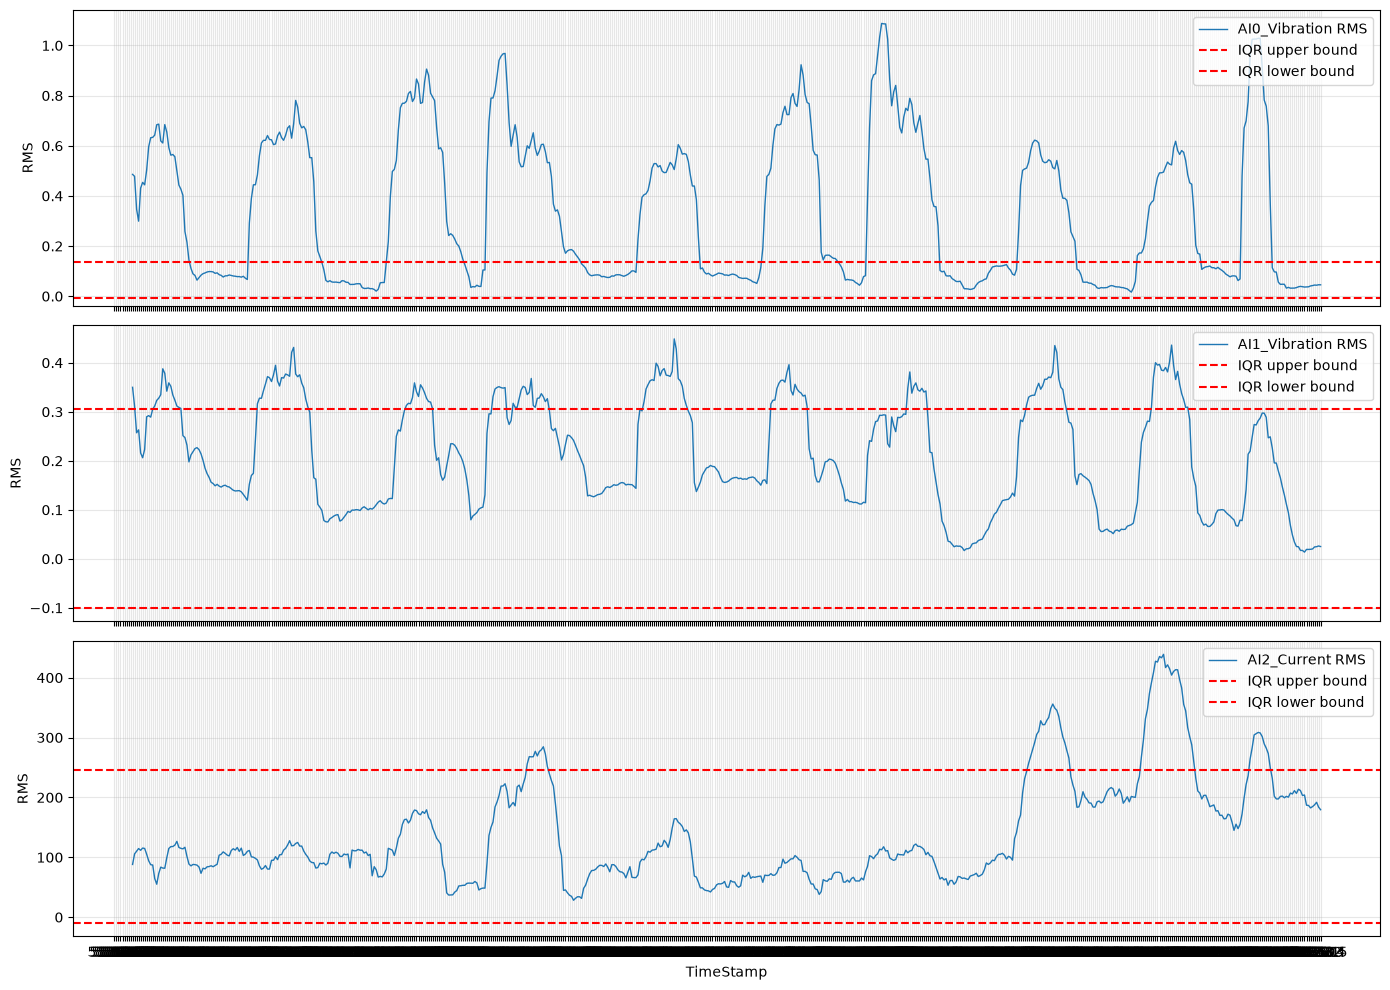

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



DATA_DIR = Path.cwd().parent / "data"
NORMAL_PATH = DATA_DIR / "press_data_normal.csv"
OUTLIER_PATH = DATA_DIR / "outlier_data.csv"
# 데이터 읽기

SIGNAL_COLUMNS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
# 사용할 센서 정의 

WINDOW_SAMPLES = 10  # 0.1-second sampling, so this is a 1-second RMS window
# 샘플 하나 크기 0.1초 가정

def load_press_data(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path, index_col=0)
    data["TimeStamp"] = data["TimeStamp"].astype(str)
    return data
# 데이터 읽기

def add_rolling_rms(data: pd.DataFrame, window: int = WINDOW_SAMPLES) -> pd.DataFrame:
    result = data.copy()
    for column in SIGNAL_COLUMNS:
        result[f"{column}_RMS"] = np.sqrt(
            result[column].pow(2).rolling(window=window, min_periods=window).mean()
        )
    return result
# RMS 계산

def iqr_bounds(normal_rms: pd.DataFrame) -> pd.DataFrame:
    bounds = {}
    for column in [f"{name}_RMS" for name in SIGNAL_COLUMNS]:
        q1 = normal_rms[column].quantile(0.25)
        q3 = normal_rms[column].quantile(0.75)
        iqr = q3 - q1
        bounds[column] = {
            "lower": q1 - 1.5 * iqr,
            "upper": q3 + 1.5 * iqr,
            "q1": q1,
            "q3": q3,
        }
    return pd.DataFrame(bounds).T
# 정상 데이터의 기준 만들기

normal = add_rolling_rms(load_press_data(NORMAL_PATH))
outlier = add_rolling_rms(load_press_data(OUTLIER_PATH))
rms_columns = [f"{name}_RMS" for name in SIGNAL_COLUMNS]
bounds = iqr_bounds(normal[rms_columns])

# Detect rows where at least one sensor's rolling RMS is outside the normal range.
outlier_flags = pd.DataFrame(index=outlier.index)
for column in rms_columns:
    outlier_flags[f"{column}_outlier"] = (
        (outlier[column] < bounds.loc[column, "lower"])
        | (outlier[column] > bounds.loc[column, "upper"])
    )
outlier["RMS_outlier"] = outlier_flags.any(axis=1)

print("Normal RMS summary")
display(normal[rms_columns].describe().T)
print("IQR thresholds learned from normal data")
display(bounds[["lower", "upper"]])
print(
    f"Outlier RMS rows: {outlier['RMS_outlier'].sum()} / {len(outlier)} "
    f"({outlier['RMS_outlier'].mean() * 100:.2f}%)"
)
display(outlier.loc[outlier["RMS_outlier"], ["TimeStamp", *rms_columns]].head(20))

fig, axes = plt.subplots(len(SIGNAL_COLUMNS), 1, figsize=(14, 10), sharex=True)
for axis, signal in zip(axes, SIGNAL_COLUMNS):
    rms_column = f"{signal}_RMS"
    axis.plot(outlier["TimeStamp"], outlier[rms_column], label=f"{signal} RMS", linewidth=1)
    axis.axhline(bounds.loc[rms_column, "upper"], color="red", linestyle="--", label="IQR upper bound")
    axis.axhline(bounds.loc[rms_column, "lower"], color="red", linestyle="--", label="IQR lower bound")
    axis.set_ylabel("RMS")
    axis.legend(loc="upper right")
    axis.grid(alpha=0.3)
axes[-1].set_xlabel("TimeStamp")
plt.tight_layout()
plt.show()


[normal]
rows: 20,000
time range: 00:00.0 ~ 16:55.8
median sample interval: 0.1000 sec
duplicate/non-increasing timestamps: 3
large time gaps (> 1.5x median): 598
missing values in signal columns: 0

[outlier]
rows: 600
time range: 51:07.9 ~ 53:53.5
median sample interval: 0.1000 sec
duplicate/non-increasing timestamps: 0
large time gaps (> 1.5x median): 20
missing values in signal columns: 0

Normal reference data
normal rows: 19,900 / 20,000


,segment_id,start_index,end_index,start_time,end_time,sample_count,duration_seconds
count,623.000000,623.000000,623.000000,623,623,623.000000,623.000000
unique,NaN,NaN,NaN,618,622,NaN,NaN
top,NaN,NaN,NaN,04:32.5,43:33.2,NaN,NaN
freq,NaN,NaN,NaN,2,2,NaN,NaN
mean,325.401284,10102.497592,10133.439807,NaN,NaN,31.942215,3.094222
std,189.286644,5629.839521,5629.160147,NaN,NaN,16.814762,1.681476
min,2.000000,9.000000,40.000000,NaN,NaN,1.000000,0.000000
25%,161.500000,5352.500000,5378.000000,NaN,NaN,17.000000,1.600000
50%,323.000000,10211.000000,10231.000000,NaN,NaN,35.000000,3.400000
75%,490.500000,14789.000000,14825.500000,NaN,NaN,50.000000,4.900000


Outlier data: normal segments found by normal RMS bounds
normal rows: 260 / 600


,segment_id,start_index,end_index,start_time,end_time,sample_count,duration_seconds
0,3,38,53,51:20.1,51:21.6,16,1.5
1,4,54,66,51:23.6,51:24.8,13,1.2
2,7,103,131,51:31.9,51:34.7,29,2.8
3,8,132,135,51:40.0,51:40.3,4,0.3
4,12,174,184,51:58.8,51:59.8,11,1.0
5,15,232,242,52:07.3,52:08.3,11,1.0
6,16,243,259,52:12.6,52:14.2,17,1.6
7,21,291,321,52:39.3,52:42.3,31,3.0
8,24,360,371,52:48.7,52:49.8,12,1.1
9,25,372,373,52:53.8,52:53.9,2,0.1


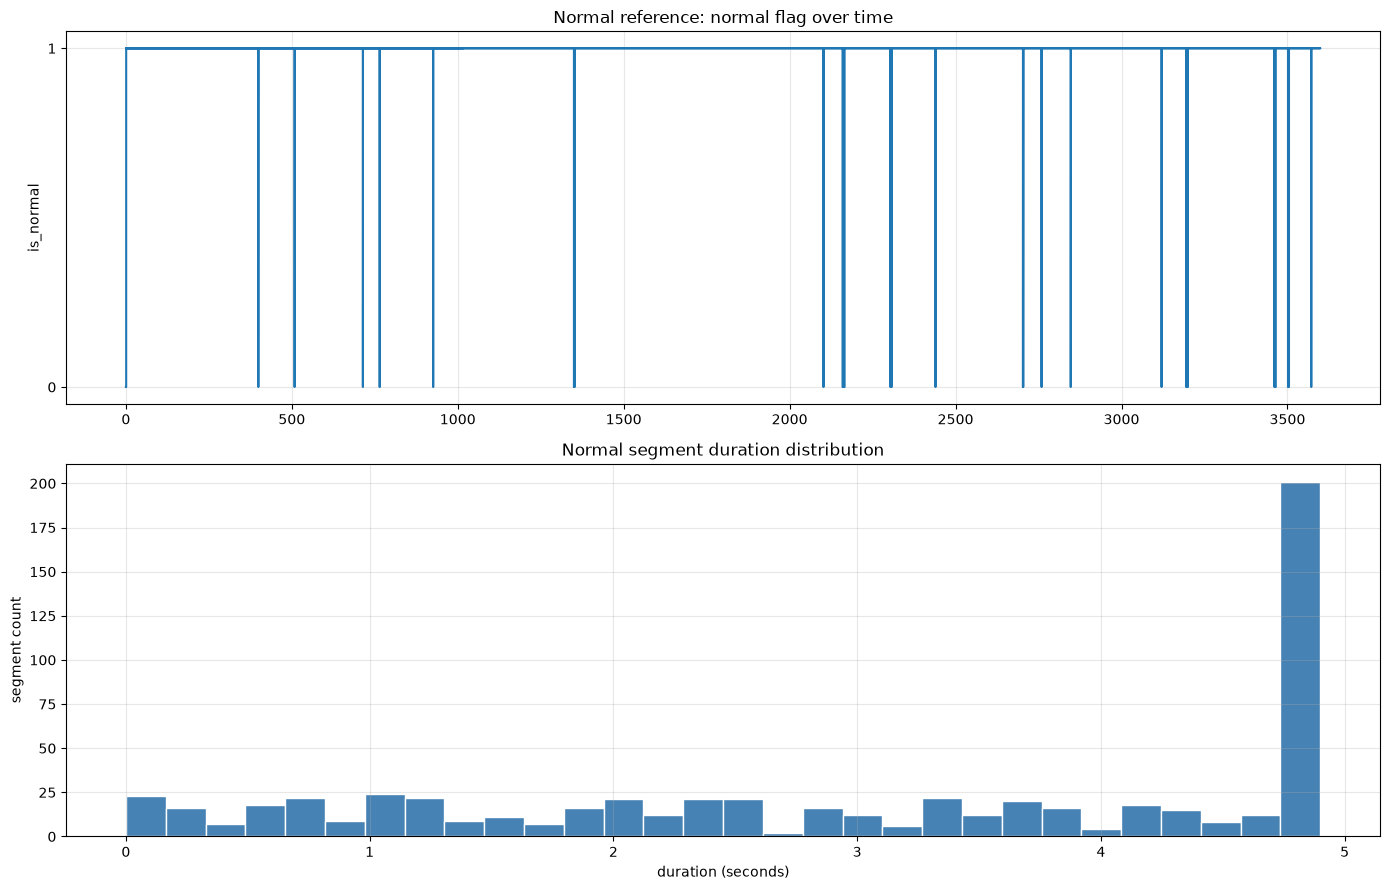

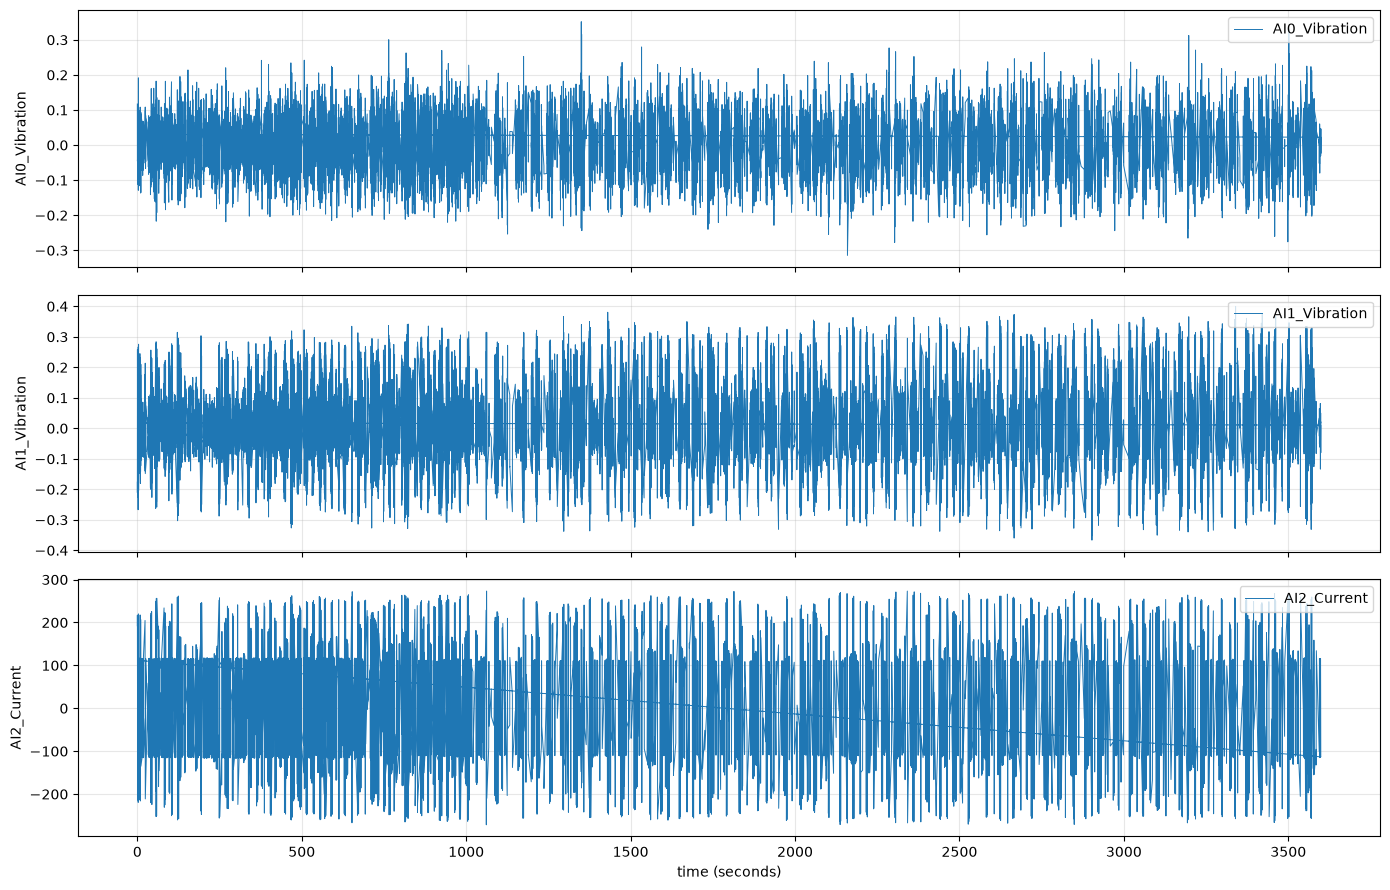

,AI0_Vibration,AI1_Vibration,AI2_Current
AI0_Vibration,1.000000,0.368274,0.004091
AI1_Vibration,0.368274,1.000000,0.000578
AI2_Current,0.004091,0.000578,1.000000


normal_segments: 623개


In [ ]:
# 시계열 구조 분석 및 정상 segment 후보 추출
# Cell 1, 2에서 생성된 normal, outlier, bounds, rms_columns을 재사용합니다.

import matplotlib.pyplot as plt


def timestamp_to_seconds(timestamp: pd.Series) -> pd.Series:
    """MM:SS.s 형식의 TimeStamp를 초 단위 숫자로 변환합니다."""
    parts = timestamp.astype(str).str.split(":", expand=True)
    return pd.to_numeric(parts[0], errors="coerce") * 60 + pd.to_numeric(
        parts[1], errors="coerce"
    )
## 문자열 --> 시간

def add_time_structure(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()
    result["row_index"] = result.index
    result["time_seconds"] = timestamp_to_seconds(result["TimeStamp"])
    result["sample_interval"] = result["time_seconds"].diff()
    return result
## 시간간격 계산

def add_normal_flag(data: pd.DataFrame, bounds: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()
    valid_rms = result[rms_columns].notna().all(axis=1)
    in_normal_range = pd.DataFrame(index=result.index)

    for column in rms_columns:
        in_normal_range[column] = result[column].between(
            bounds.loc[column, "lower"],
            bounds.loc[column, "upper"],
        )

    # 모든 센서의 RMS가 정상 범위 안에 있는 행만 정상으로 판정합니다.
    result["is_normal"] = valid_rms & in_normal_range.all(axis=1)
    return result


def add_segment_id(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()
    valid_intervals = result["sample_interval"].dropna()
    positive_intervals = valid_intervals[valid_intervals > 0]
    typical_interval = positive_intervals.median()

    # 큰 gap, timestamp 역행, 정상 여부 변화는 모두 새로운 구간의 시작입니다.
    large_gap = result["sample_interval"] > typical_interval * 1.5
    timestamp_reset = result["sample_interval"] <= 0
    state_change = result["is_normal"] != result["is_normal"].shift()
    boundary = large_gap | timestamp_reset | state_change.fillna(True)
    result["segment_id"] = boundary.fillna(False).cumsum()
    result["typical_interval"] = typical_interval
    return result


def summarize_normal_segments(data: pd.DataFrame) -> pd.DataFrame:
    normal_data = data[data["is_normal"]].copy()
    return (
        normal_data.groupby("segment_id", sort=True)
        .agg(
            start_index=("row_index", "min"),
            end_index=("row_index", "max"),
            start_time=("TimeStamp", "first"),
            end_time=("TimeStamp", "last"),
            sample_count=("is_normal", "size"),
            duration_seconds=("time_seconds", lambda values: values.max() - values.min()),
        )
        .reset_index()
    )


# 1) 시간축의 기본 구조 확인
normal_ts = add_time_structure(normal)
outlier_ts = add_time_structure(outlier)

for name, data in {"normal": normal_ts, "outlier": outlier_ts}.items():
    intervals = data["sample_interval"].dropna()
    positive_intervals = intervals[intervals > 0]
    print(f"[{name}]")
    print(f"rows: {len(data):,}")
    print(f"time range: {data['TimeStamp'].iloc[0]} ~ {data['TimeStamp'].iloc[-1]}")
    print(f"median sample interval: {positive_intervals.median():.4f} sec")
    print(f"duplicate/non-increasing timestamps: {(intervals <= 0).sum():,}")
    print(f"large time gaps (> 1.5x median): {(intervals > positive_intervals.median() * 1.5).sum():,}")
    print(f"missing values in signal columns: {data[SIGNAL_COLUMNS].isna().sum().sum():,}")
    print()

# 2) 정상 RMS 기준으로 정상/비정상 행 판정
normal_ts = add_normal_flag(normal_ts, bounds)
outlier_ts = add_normal_flag(outlier_ts, bounds)

# 3) 정상 여부 변화와 시간 gap을 기준으로 연속 구간 생성
normal_ts = add_segment_id(normal_ts)
outlier_ts = add_segment_id(outlier_ts)

# 4) 정상 구간 요약
normal_segment_summary = summarize_normal_segments(normal_ts)
outlier_normal_segment_summary = summarize_normal_segments(outlier_ts)

print("Normal reference data")
print(f"normal rows: {normal_ts['is_normal'].sum():,} / {len(normal_ts):,}")
display(normal_segment_summary.describe(include="all"))

print("Outlier data: normal segments found by normal RMS bounds")
print(f"normal rows: {outlier_ts['is_normal'].sum():,} / {len(outlier_ts):,}")
display(outlier_normal_segment_summary.head(20))

# 5) 너무 짧은 구간을 제거하기 전 정상 구간 길이 분포 확인
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(normal_ts["time_seconds"], normal_ts["is_normal"].astype(int), drawstyle="steps-post")
axes[0].set_title("Normal reference: normal flag over time")
axes[0].set_ylabel("is_normal")
axes[0].set_yticks([0, 1])
axes[0].grid(alpha=0.3)

axes[1].hist(
    normal_segment_summary["duration_seconds"],
    bins=30,
    color="steelblue",
    edgecolor="white",
)
axes[1].set_title("Normal segment duration distribution")
axes[1].set_xlabel("duration (seconds)")
axes[1].set_ylabel("segment count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6) 센서별 시계열 구조와 상관관계 확인
fig, axes = plt.subplots(len(SIGNAL_COLUMNS), 1, figsize=(14, 9), sharex=True)
for axis, signal in zip(axes, SIGNAL_COLUMNS):
    axis.plot(normal_ts["time_seconds"], normal_ts[signal], linewidth=0.7, label=signal)
    axis.set_ylabel(signal)
    axis.grid(alpha=0.3)
    axis.legend(loc="upper right")
axes[-1].set_xlabel("time (seconds)")
plt.tight_layout()
plt.show()

display(normal_ts[SIGNAL_COLUMNS].corr())

# 이후 분석에서 사용할 객체
normal_segments = [
    segment.copy()
    for _, segment in normal_ts[normal_ts["is_normal"]].groupby("segment_id", sort=True)
]

print(f"normal_segments: {len(normal_segments)}개")